## Dataset selector

In [70]:
import ipywidgets as widgets
from IPython.display import display as ipy_display

# ── Dataset selector ─────────────────────────────────
dataset_selector = widgets.Dropdown(
    options={
        "low (rank=10, full rank)":  "../data/artificial_lowrank/low",
        "high (rank=3, low rank)":   "../data/artificial_lowrank/high",
    },
    value="../data/artificial_lowrank/low",
    description="Dataset:",
)
ipy_display(dataset_selector)

Dropdown(description='Dataset:', options={'low (rank=10, full rank)': '../data/artificial_lowrank/low', 'high …

## Outlier Target Selection

This dataset is generated by discretizing a rank-r latent signal with additive noise
(see `generate_synthetic_lowrank.py`):

```
Eta_signal = U @ V.T       # rank-r latent signal
Eta = Eta_signal + noise    # add Gaussian noise
X = digitize(Eta, percentile_thresholds)  # discretize into K=5 ordinal bins
```

Because percentile-based binning is used, each column's marginal distribution is
perfectly uniform (~20% per value). Per-column rarity scoring is therefore ineffective.

Instead, we use **PCA reconstruction error** as the outlier score:
fit a rank-r PCA to the discretized data and measure how poorly each record
is reconstructed. Records far from the low-rank manifold are outliers.

**Selection pipeline:**

1. **PCA fit** — Standardize features and fit PCA with `n_components = r`
2. **Reconstruction error** — Project each record onto the rank-r subspace and measure squared reconstruction error
3. **Top-N selection** — Pick the records with the highest reconstruction error

In [77]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# ── Parameters ─────────────────────────────────────
N_TARGETS = 5      # number of outlier records to select

# ── Dataset rank mapping ───────────────────────────
DATASET_RANK = {
    "low":  10,  # full rank
    "high": 3,   # low rank
}

# ── Data loading ────────────────────────────────────
DATA_DIR = dataset_selector.value
df_raw = pd.read_csv(f"{DATA_DIR}.csv")
variant = DATA_DIR.rsplit("/", 1)[-1]  # "low" or "high"
df_raw["ID"] = [f"ID{i}" for i in range(len(df_raw))]
df = df_raw.set_index("ID")

feat_cols = df.columns.tolist()
TARGET_RANK = DATASET_RANK[variant]

print(f"Dataset: {DATA_DIR}")
print(f"Shape: {df.shape}")
print(f"Feature columns ({len(feat_cols)}): {feat_cols}")
print(f"Target rank for PCA: {TARGET_RANK}")

Dataset: ../data/artificial_lowrank/high
Shape: (20000, 10)
Feature columns (10): ['attr_0', 'attr_1', 'attr_2', 'attr_3', 'attr_4', 'attr_5', 'attr_6', 'attr_7', 'attr_8', 'attr_9']
Target rank for PCA: 3


### Step 1 — PCA fit and explained variance

Standardize features and fit PCA. Show explained variance to confirm the rank structure.

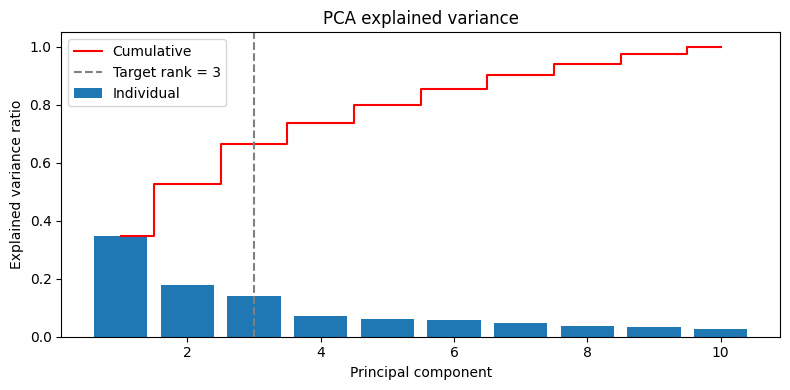

Explained variance ratio: [0.3474 0.1786 0.1402 0.0704 0.0616 0.0572 0.0483 0.0365 0.0334 0.0263]
Cumulative (first 3): 0.6662


In [78]:
X = df[feat_cols].values.astype(float)
scaler = StandardScaler()
X_std = scaler.fit_transform(X)

# Full PCA to show variance structure
pca_full = PCA()
pca_full.fit(X_std)

fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(range(1, len(feat_cols) + 1), pca_full.explained_variance_ratio_, label="Individual")
ax.step(range(1, len(feat_cols) + 1), np.cumsum(pca_full.explained_variance_ratio_),
        where="mid", label="Cumulative", color="red")
ax.axvline(x=TARGET_RANK, color="gray", linestyle="--", label=f"Target rank = {TARGET_RANK}")
ax.set_xlabel("Principal component")
ax.set_ylabel("Explained variance ratio")
ax.set_title("PCA explained variance")
ax.legend()
plt.tight_layout()
plt.show()

print(f"Explained variance ratio: {np.round(pca_full.explained_variance_ratio_, 4)}")
print(f"Cumulative (first {TARGET_RANK}): {np.cumsum(pca_full.explained_variance_ratio_[:TARGET_RANK])[-1]:.4f}")

### Step 2 — Reconstruction error

Project onto the rank-r subspace and measure squared reconstruction error per record.

Reconstruction error stats:
count    20000.000000
mean         3.337703
std          1.859729
min          0.071458
25%          1.923367
50%          3.024095
75%          4.410226
max         13.432261
Name: recon_error, dtype: float64


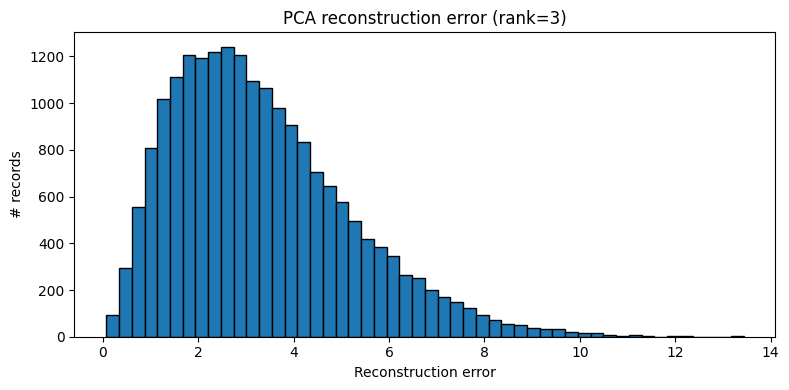

In [79]:
pca = PCA(n_components=TARGET_RANK)
X_reduced = pca.fit_transform(X_std)
X_reconstructed = pca.inverse_transform(X_reduced)
recon_error = np.sum((X_std - X_reconstructed) ** 2, axis=1)

df["recon_error"] = recon_error

print("Reconstruction error stats:")
print(df["recon_error"].describe())

fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(recon_error, bins=50, edgecolor="black")
ax.set_xlabel("Reconstruction error")
ax.set_ylabel("# records")
ax.set_title(f"PCA reconstruction error (rank={TARGET_RANK})")
plt.tight_layout()
plt.show()

### Step 3 — Final selection: top N records

Select the `N_TARGETS` records with the highest reconstruction error.

In [80]:
df_sorted = df.sort_values("recon_error", ascending=False)
selected_ids = df_sorted.index[:N_TARGETS].tolist()

result_rows = []
for sid in selected_ids:
    result_rows.append({
        "selected ID":    sid,
        "recon_error":    round(df.loc[sid, "recon_error"], 4),
    })

result_df = pd.DataFrame(result_rows).set_index("selected ID")
display(result_df)

print("\nSelected IDs:", str(selected_ids).replace("'", '"'))

,recon_error
selected ID,
ID3603,13.4323
ID19202,12.3569
ID4393,12.2995
ID2047,12.2058
ID17790,11.9032



Selected IDs: ["ID3603", "ID19202", "ID4393", "ID2047", "ID17790"]


In [81]:
# Inspect the raw data of selected records
display(df.loc[selected_ids, feat_cols])

,attr_0,attr_1,attr_2,attr_3,attr_4,attr_5,attr_6,attr_7,attr_8,attr_9
ID,,,,,,,,,,
ID3603,4,0,4,4,4,1,3,0,0,2
ID19202,4,0,4,0,1,1,4,0,1,1
ID4393,4,1,4,4,1,0,0,4,0,1
ID2047,0,0,4,1,3,4,2,3,0,0
ID17790,2,4,0,1,0,2,3,4,4,4


# Distribution of each column

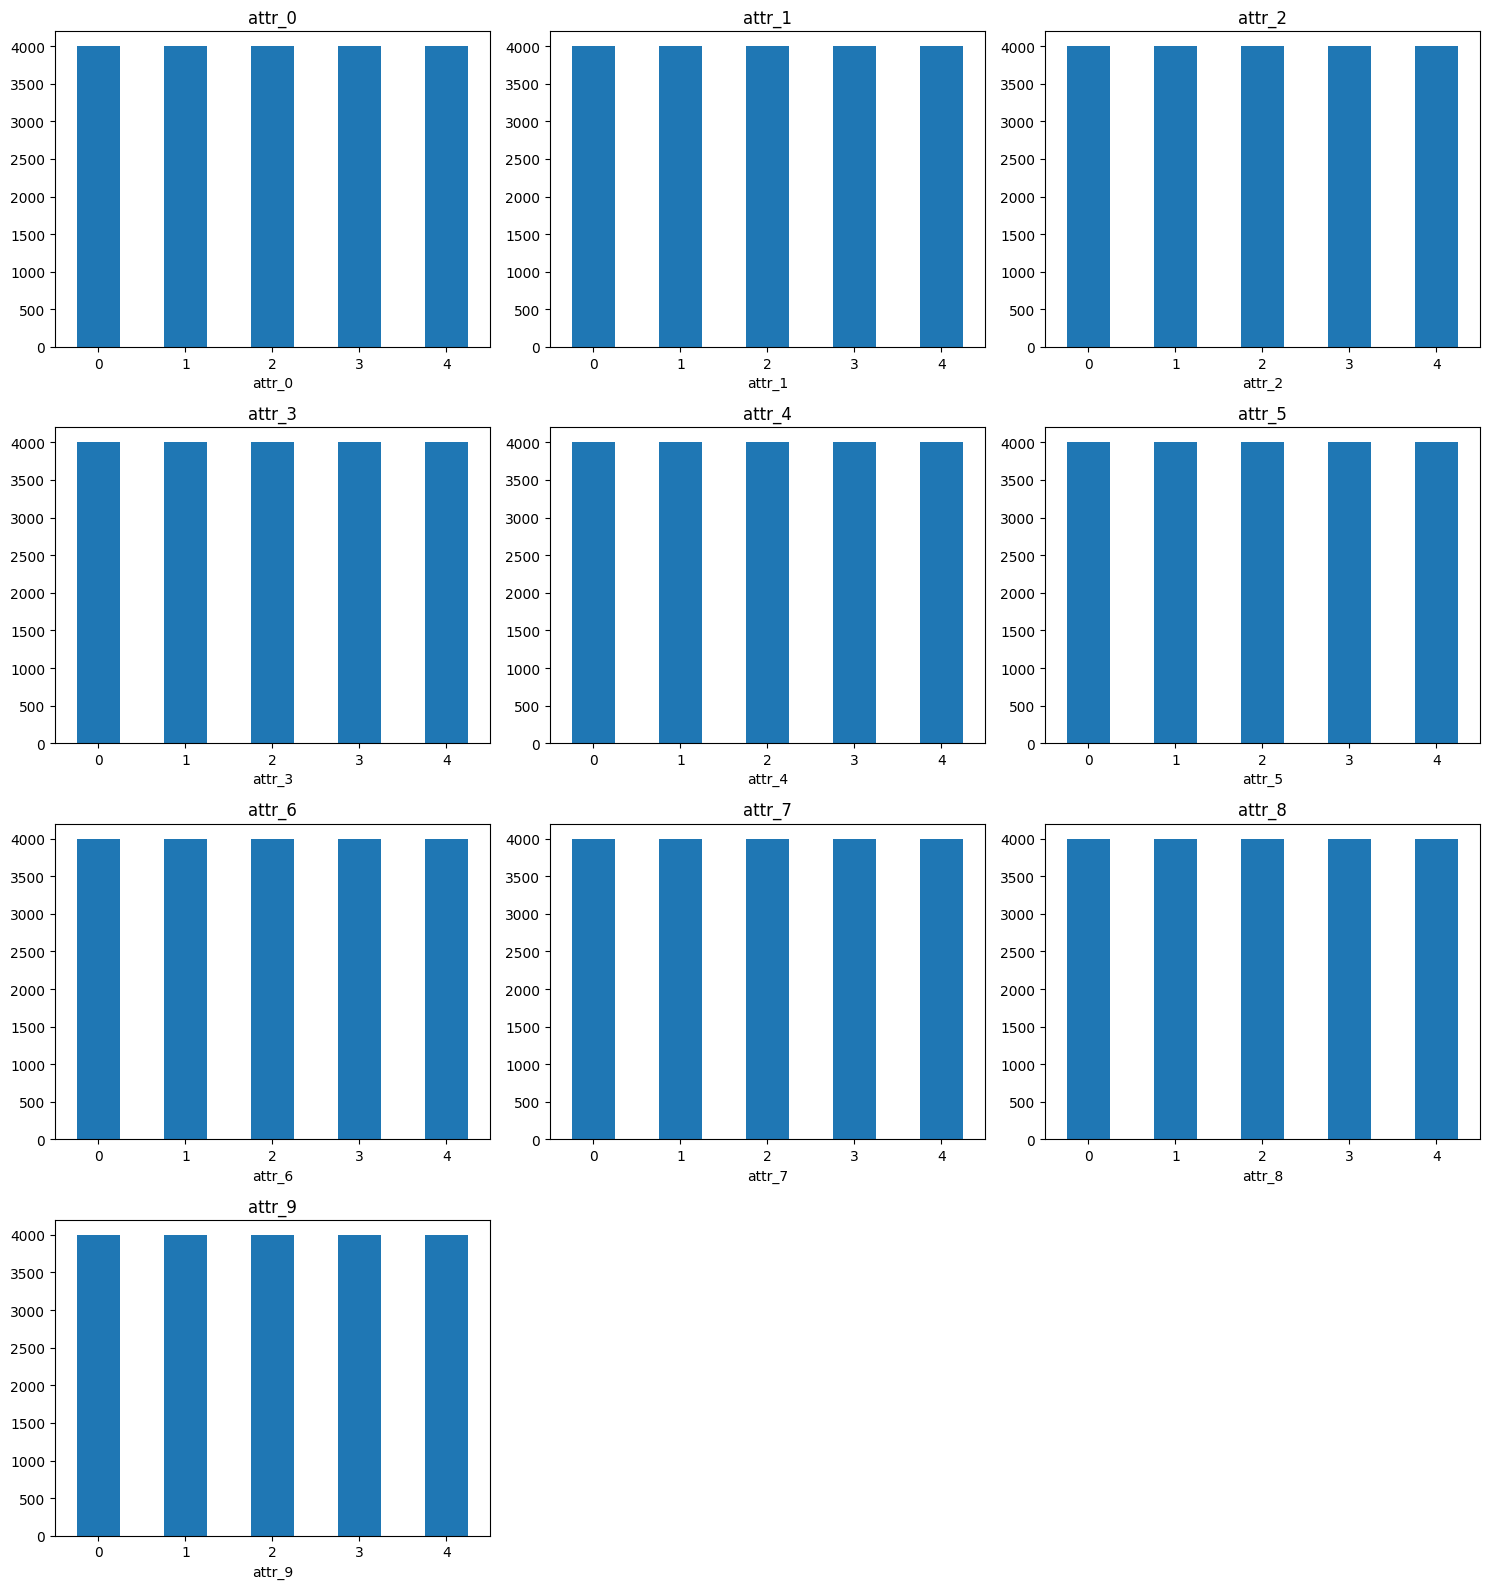

In [82]:
df_dist = pd.read_csv(f"{DATA_DIR}.csv")
feat_cols_dist = df_dist.columns.tolist()

# ── Distribution of each column ────────────────────────
n = len(feat_cols_dist)

fig, axes = plt.subplots(
    nrows=(n + 2) // 3,
    ncols=3,
    figsize=(15, 4 * ((n + 2) // 3))
)
axes = axes.flatten()

# All columns are Ordinal (0-4) → bar chart
for ax, col in zip(axes, feat_cols_dist):
    df_dist[col].value_counts().sort_index().plot(kind='bar', ax=ax)
    ax.set_title(col)
    ax.tick_params(axis='x', rotation=0)

# Hide unused subplots
for ax in axes[n:]:
    ax.set_visible(False)

plt.tight_layout()
plt.show()